# Integrals 1 notebook

*(Adapted from https://github.com/vlvovch/PHYS6350-ComputationalPhysics)*

## Rectangular method

Use 
$$
\int_a^b f(x) dx \approx h \sum_{k=1}^N f(x_k), \qquad k = 1,\ldots, N
$$
with
$$
h = \frac{(b-a)}{N}
$$
and
$$
x_k = a + \frac{2k-1}{2} h
$$

Below, we visualize this approach for $f(x) = x^4 - 2x + 3$ between $a = 0.0$ and $b = 2.0$. We can calculate the solution analytically. The integral is:

$$
\begin{align}
I = \int_{0.0}^{2.0} (x^4 - 2x + 3) dx = (-\frac{1}{5}x^5 - x^2 + 3x)\rvert_{0.0}^{2.0} = 8.4
\end{align}
$$

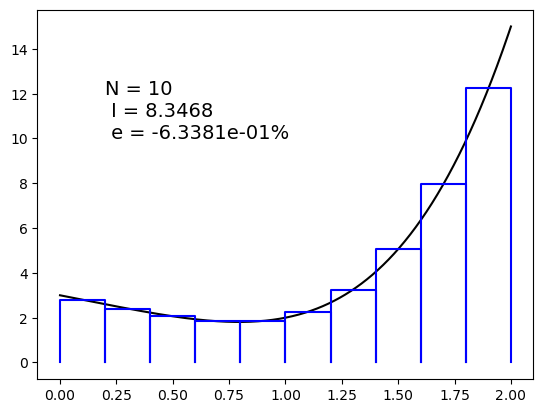

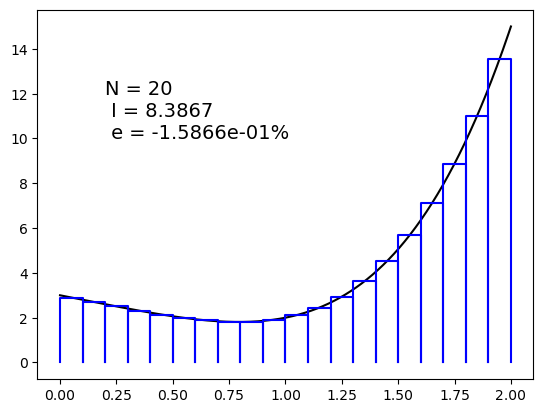

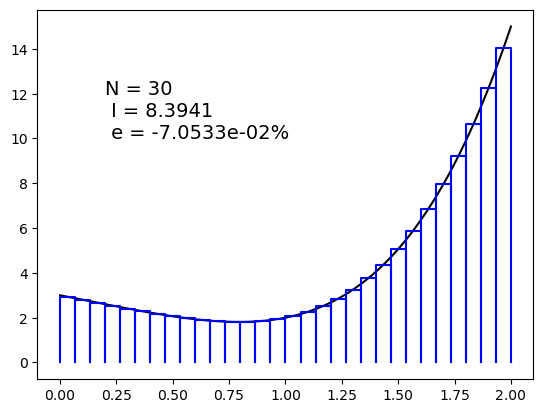

In [79]:
import numpy as np 
import matplotlib.pyplot as plt 

# Define the rectangular method
def integrate_rect(f, a, b, N):
    h = (b-a)/N
    integral = 0.0
    x = np.array([], dtype='float')
    for k in range(1,N+1):
        xk = a+(2*k-1)*h/2
        x = np.append(x, xk)
        integral = integral + h*f(xk)
    return [integral, x, h]
    
# Function to integrate
def fx(x):
    return x**4 - 2*x + 3

# Test different values of N
N = np.array([10,20,30])
a = 0.0
b = 2.0
x = np.linspace(a, b, num=1000)

for n in N:
    integral, xk, h = integrate_rect(fx, a, b, n)
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(x, fx(x), 'k')    

    for i in range(len(xk)):
        ax.plot([xk[i]-h/2, xk[i]-h/2, xk[i]+h/2, xk[i]+h/2], [0, fx(xk[i]), fx(xk[i]), 0], 'b')

    ax.text(0.2, 10, f"N = {n} \n I = {integral:.4f} \n e = {(integral-8.4)/8.4*100:.4e}%", fontsize=14)


In the figures above $e$ represents the error.

## Trapezoid method

Use

$$
\int_a^b f(x)dx \approx h \sum_{k=0}^{N-1} \frac{f(x_{k}) + f(x_{k+1})}{2}, \qquad k = 0,\ldots, N-1
$$
with
$$
N = \frac{(b-a)}{N}
$$
and
$$
x_k = a +  k h
$$

We repeat below the same example as for the rectangular method.

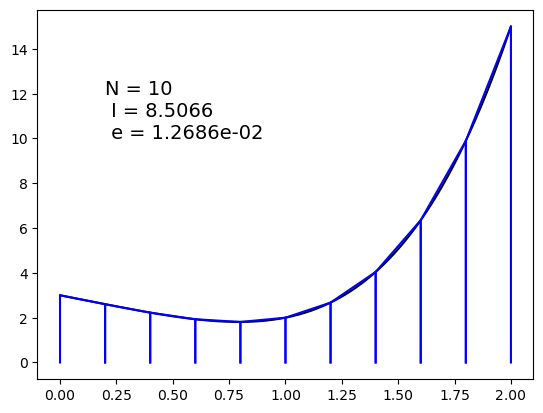

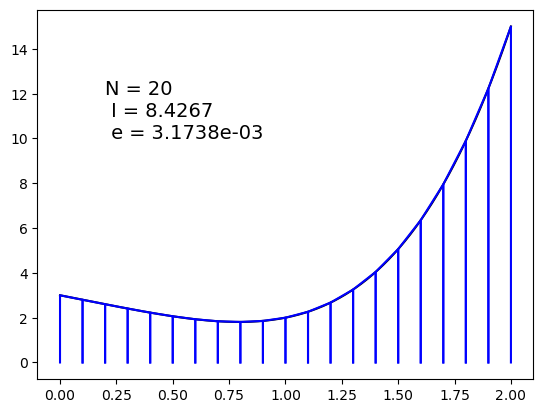

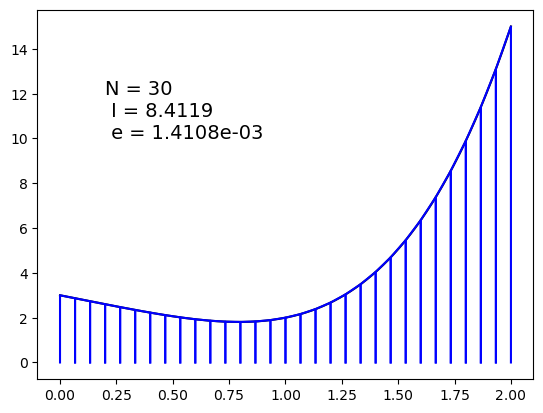

In [80]:
# Trapezoid method of integration
def integrate_trap(f, a, b, N):
    h = (b-a)/N 
    integral = 0.0
    x = np.array([], dtype='float')
    for k in range(0,N):
        xk = a + k*h 
        x = np.append(x, xk)
        integral = integral + 0.5*(f(xk) + f(xk+h))*h
    return [integral, x, h]

# Test different values of N
for n in N:
    integral, xk, h = integrate_trap(fx, a, b, n)
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(x, fx(x), 'k')    

    for i in range(len(xk)):
        ax.plot([xk[i], xk[i], xk[i]+h, xk[i]+h], [0, fx(xk[i]), fx(xk[i]+h), 0], 'b')

    ax.text(0.2, 10, f"N = {n} \n I = {integral:.4f} \n e = {(integral-8.4)/8.4:.4e}", fontsize=14)

## Simpson method

Use

$$
\int_a^bf(x)dx \approx \frac{h}{3}\left[ f(a) + f(b) + 4 \sum_{k=1}^{N/2}f(a+(2k-1)h) + 2\sum_{k=1}^{N/2-1}f(a+2kh)\right]
$$

with

$$
h = \frac{(b-a)}{h}
$$

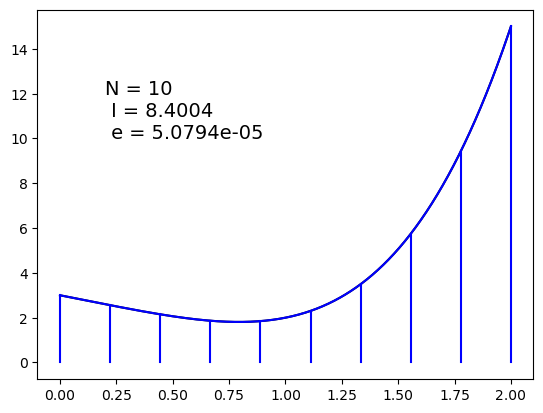

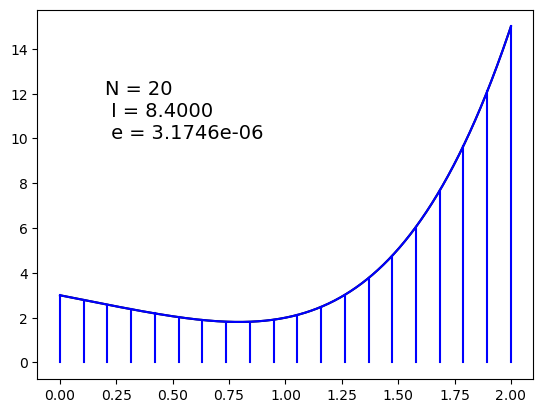

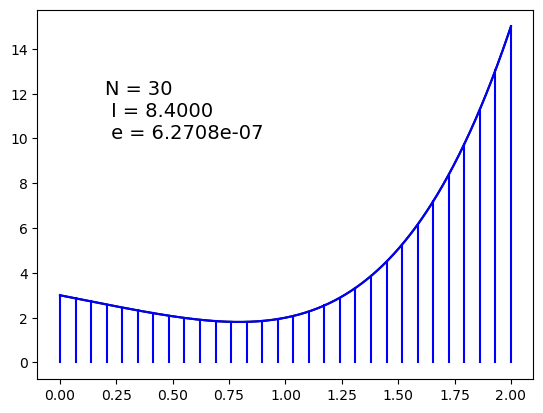

In [106]:
def integrate_simp(f, a, b, N):
    h = (b-a)/N
    x_odd = a + np.arange(1,N,2)*h
    x_even = a + np.arange(2,N-1,2)*h 

    integral = (h/3.0)*(f(a)+f(b)+4*np.sum(f(x_odd))+2*np.sum(f(x_even)))

    x = np.linspace(a, b, num=N)

    return [integral, x, h]

def y_quad(f, X, h):
    result = np.array([])
    for x in X:
        A = (1/(2*h**2)) * (f(x-h) - 2*f(x) + f(x+h))
        B = (f(x+h)*(1-2*x/h)-f(x-h)*(1+2*x/h)+f(x)*4*x/h)/(2*h)
        C = f(x) - A*x**2-B*x
        result = np.append(result, A*x**2+B*x+C)
    return result

# Test different values of N
for n in N:
    integral, xk, h = integrate_simp(fx, a, b, n)
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(x, fx(x), 'k')    

    #print(f"For N = {n}, the integral returns {integral}, corresponding to a {(integral-8.4)/8.4*100}% error.")

    ax.plot(x, y_quad(fx, x, h), 'b')
    
    for i in range(xk.size):
        ax.plot([xk[i], xk[i]], [0, fx(xk[i])], 'b')

    ax.text(0.2, 10, f"N = {n} \n I = {integral:.4f} \n e = {(integral-8.4)/8.4:.4e}", fontsize=14)

## Provided packages

There are existing functions in the numpy and scipy libraries that can perform integrations. 